In [1]:
# # Install required packages from requirements.txt
# import subprocess
# import sys
# from pathlib import Path

# # List of packages to install (excluding git packages)
# packages = [
#     "qiskit==1.4.2",
#     "qutip==5.1.1",
#     "qiskit_dynamics==0.5.1",
#     "qiskit_aer==0.17.0",
#     "scikit-learn",
#     "scipy",
#     "networkx",
# ]

# for package in packages:
#     try:
#         print(f"Installing {package}...")
#         subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
#     except:
#         print(f"  (skipped or already installed)")
        
# print("Installation complete!")

In [2]:
# Import required packages
import qiskit
import qiskit_dynamics
import qiskit_aer
import qutip
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / "src"

sys.path.append(str(SRC_PATH))

from qrc.config import get_default_config
from qrc.setup import setup_qrc_system
from qrc.utils import log_negativity_qt

In [4]:
cfg = get_default_config()

cfg

{'f0': 1.75,
 'Js': 0.5,
 'gamma_scale': 0.2,
 't_final': 25.0,
 't_equi': 0.0,
 'delta_t': 0.024999999999999998,
 'n_qubits': 8,
 'n_steps': 1002,
 't_eval': array([0.0000000e+00, 2.4975025e-02, 4.9950050e-02, ..., 2.4950050e+01,
        2.4975025e+01, 2.5000000e+01], shape=(1002,)),
 't_span': [0.0, 25.0],
 'n_bet': 300,
 'Delta_t': 7.499999999999999,
 'n_injects': 3,
 'n_samples': 10,
 'DeltaDelta_t': 0.7499999999999999,
 'n_data': 30,
 'h_z': 1.5,
 'gamma': 0.01}

In [5]:
system = setup_qrc_system(
    n_qubits=cfg["n_qubits"],
    f0=cfg["f0"],
    gamma_scale=cfg["gamma_scale"],
    coupling_strength=cfg["Js"],
    h_z=cfg["h_z"],
    gamma=cfg["gamma"],
    t_final=cfg["t_final"],
    delta_t=cfg["delta_t"],
    n_samples=cfg["n_samples"],
    n_injects=cfg["n_injects"],
)

system.keys()

dict_keys(['x_ops', 'y_ops', 'z_ops', 'x_mat', 'y_mat', 'z_mat', 'identity', 'zeros', 'rho_0_op', 'rho_0', 't_eval', 't_span', 'sequences', 'sk1', 'sk2', 'coupling_matrices', 'J', 'J_x', 'H', 'L_ops', 'L_mat', 'reservoir_z'])

In [6]:
H = system["H"]
rho_0 = system["rho_0"]
L_mat = system["L_mat"]
sk1 = system["sk1"]
sk2 = system["sk2"]
reservoir_z = system["reservoir_z"]

print("H shape:", H.shape)
print("rho_0 shape:", rho_0.shape)
print("Number of Lindblad operators:", len(L_mat))
print("sk1 shape:", sk1.shape)
print("reservoir_z shape:", reservoir_z.shape)

H shape: (256, 256)
rho_0 shape: (256, 256)
Number of Lindblad operators: 8
sk1 shape: (1002,)
reservoir_z shape: (8, 10, 3)


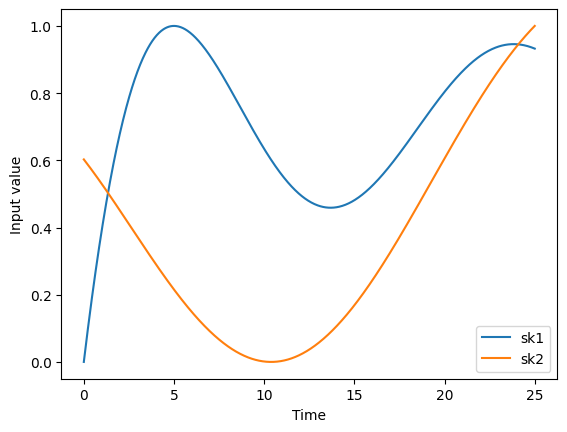

In [7]:
import matplotlib.pyplot as plt

plt.plot(system["t_eval"], sk1, label="sk1")
plt.plot(system["t_eval"], sk2, label="sk2")
plt.xlabel("Time")
plt.ylabel("Input value")
plt.legend()
plt.show()

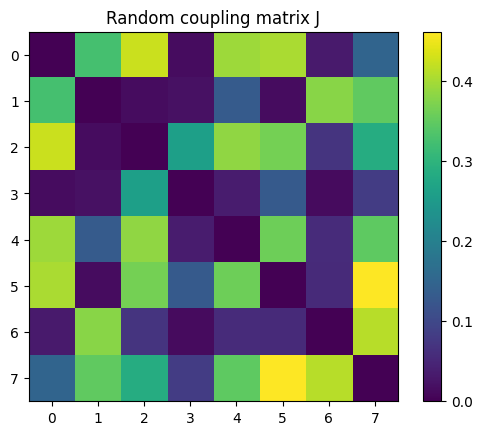

In [8]:
J = system["J"]

plt.imshow(J)
plt.colorbar()
plt.title("Random coupling matrix J")
plt.show()

In [9]:
from qrc.update_qubits import update_qubits
from qrc.dynamics import custom_evolution_rk4_update, rk4_update

In [12]:
param = {
"n_qubits": cfg["n_qubits"],
    "n_bet": cfg["n_bet"],
    "H": H,
    "L_mat": L_mat,
    "sk1": sk1,
    "sk2": sk2,
}

result = rk4_update(
    evolution_function=custom_evolution_rk4_update,
    param=param,
    t_span=cfg["t_span"],
    dt=cfg["delta_t"],
    y0=rho_0.flatten(),
    update_qubits_function=update_qubits,
)

In [14]:
result

(array([0.0000000e+00, 2.4975025e-02, 4.9950050e-02, ..., 2.4950050e+01,
        2.4975025e+01, 2.5000000e+01], shape=(1002,)),
 array([[ 1.00000000e+00+0.00000000e+00j,  9.99185930e-01-1.37863435e-26j,
          9.97745939e-01-1.23215445e-25j, ...,
          1.05152266e-02-1.10622701e-19j,  1.03668095e-02-1.10468956e-19j,
          1.02012897e-02-2.37210910e-20j],
        [ 0.00000000e+00+0.00000000e+00j, -1.24876923e-04+9.78961404e-07j,
         -2.49297677e-04+3.90552433e-06j, ...,
          5.65320683e-04+7.30878486e-03j,  8.05556644e-04+7.30692184e-03j,
          1.04210406e-03+7.28986521e-03j],
        [ 0.00000000e+00+0.00000000e+00j, -1.24872370e-04+1.37478655e-06j,
         -2.49261240e-04+5.48721481e-06j, ...,
         -6.01254288e-03+4.21094119e-03j, -5.75190448e-03+4.36133943e-03j,
         -5.48495324e-03+4.49544053e-03j],
        ...,
        [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         -1.05055392e-18+2.21002245e-17j, ...,
         -4.55080

In [16]:
n_qubits = cfg["n_qubits"]